Decision Tree Accuracy: 0.7877094972067039
Bagging Accuracy: 0.7877094972067039
Random Forest Accuracy: 0.8156424581005587
Voting Accuracy: 0.8156424581005587
AdaBoost Accuracy: 0.7988826815642458
Gradient Boosting Accuracy: 0.8044692737430168


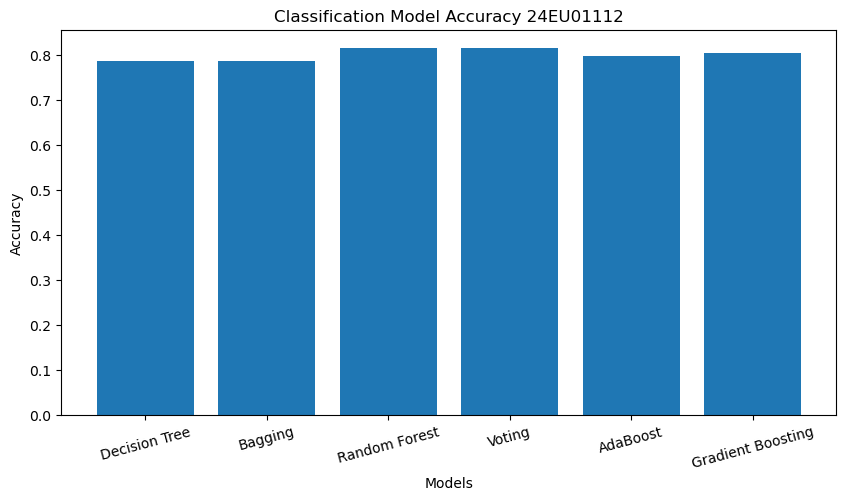

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score

data = sns.load_dataset("titanic")

data = data[['survived','pclass','sex','age','fare','sibsp','parch','embarked']]

data['age'] = data['age'].fillna(data['age'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

data = pd.get_dummies(data, drop_first=True)

X = data.drop('survived', axis=1)
y = data['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeClassifier(random_state=42)

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42
)

rf = RandomForestClassifier(random_state=42)

ada = AdaBoostClassifier(random_state=42)

gb = GradientBoostingClassifier(random_state=42)

vote = VotingClassifier(
    estimators=[
        ('dt', dt),
        ('rf', rf),
        ('ada', ada)
    ],
    voting='hard'
)

models = {
    "Decision Tree": dt,
    "Bagging": bag,
    "Random Forest": rf,
    "Voting": vote,
    "AdaBoost": ada,
    "Gradient Boosting": gb
}

accuracy = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracy.append(acc)
    print(f"{name} Accuracy: {acc}")

plt.figure(figsize=(10,5))
plt.bar(models.keys(), accuracy)

plt.title("Classification Model Accuracy 24EU01112")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.show()

Decision Tree R2 Score: 0.622075845135081
Bagging R2 Score: 0.7844762342339637
Random Forest R2 Score: 0.8051230593157366
Voting R2 Score: 0.7644301526870286
AdaBoost R2 Score: 0.5310788695468394
Gradient Boosting R2 Score: 0.7756446042829697


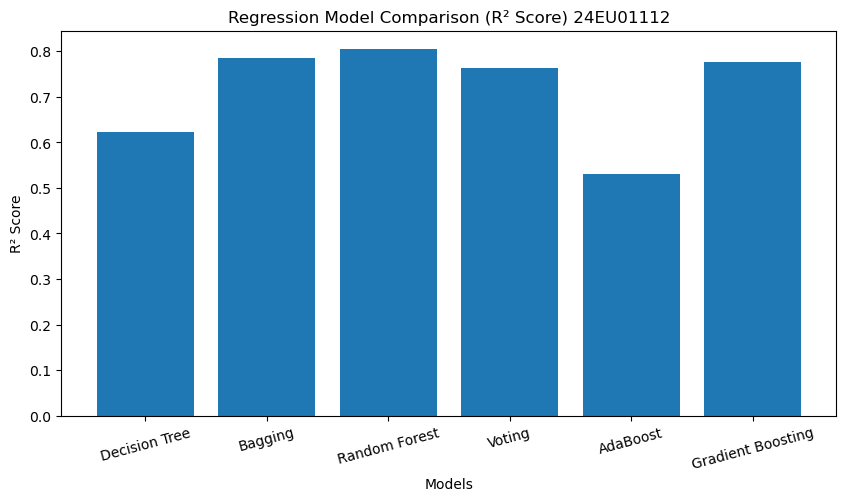

In [3]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import r2_score

housing = fetch_california_housing()

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeRegressor(random_state=42)

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    random_state=42
)

rf = RandomForestRegressor(random_state=42)

ada = AdaBoostRegressor(random_state=42)

gb = GradientBoostingRegressor(random_state=42)

vote = VotingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('rf', rf),
        ('gb', gb)
    ]
)

models = {
    "Decision Tree": dt,
    "Bagging": bag,
    "Random Forest": rf,
    "Voting": vote,
    "AdaBoost": ada,
    "Gradient Boosting": gb
}

scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = r2_score(y_test, pred)
    scores.append(score)
    print(f"{name} R2 Score: {score}")

plt.figure(figsize=(10,5))
plt.bar(models.keys(), scores)

plt.title("Regression Model Comparison (R² Score) 24EU01112")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()